# Data Visualization

In [41]:
# Import necessary libraries for visualization and data handling
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [42]:
# Load your dataset
df = pd.read_csv('Cleaned Data.csv')

# Set the visual style for Seaborn
sns.set_theme(style='whitegrid')

#### 1. LINE PLOT: trends over time

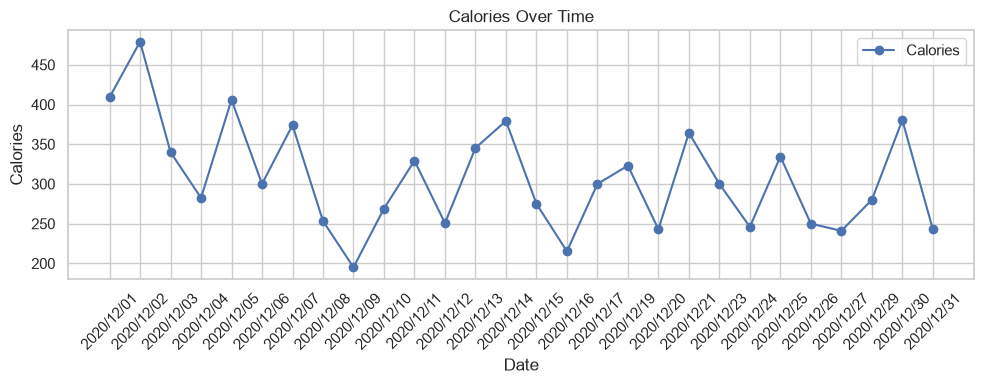

In [43]:
# 1. ( Calories burned per Date)
plt.figure(figsize=(10, 4))  # Set the figure size (width, height)
plt.plot(
    df['Date'], df['Calories'], marker='o', color='b', label='Calories'
)  # Plot line with markers
plt.title('Calories Over Time')  # Add a title
plt.xlabel('Date')  # X-axis label
plt.ylabel('Calories')  # Y-axis label
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.legend()  # Show legend
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()  # Display the plot

Findings : Calories Over Time (Line Plot): Tracks performance across days, revealing that **calories fluctuates** daily rather 
           than following a strict linear upward trajectory.

#### 2. SCATTER PLOT : showing correlation between two numerical variables 

**SCATTER PLOT : Pulse vs. Calories**

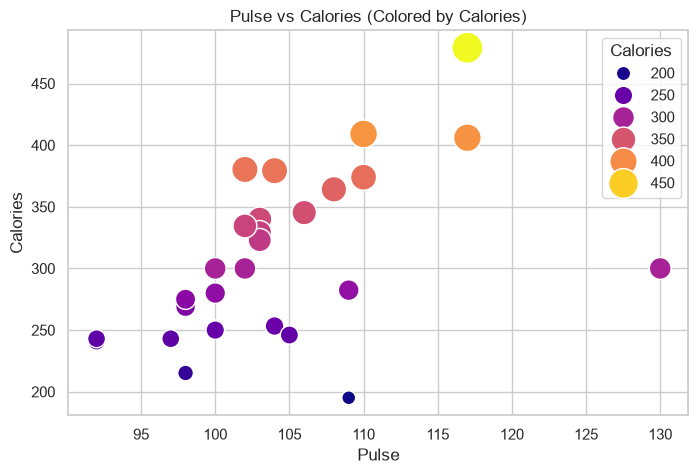

In [44]:
# 2. SCATTER PLOT (Seaborn):  showing correlation between two numerical variables (Pulse vs. Calories)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='Pulse', y='Calories', hue='Calories', palette='plasma', size='Calories', sizes=(100, 500),  # Adjusts minimum and maximum size of the circles
)
plt.title('Pulse vs Calories (Colored by Calories)')
plt.xlabel('Pulse')
plt.ylabel('Calories')
plt.show()

Findings & Interpretation: It immediately highlights that **higher calories (the bright, large clusters) align heavily with increased pulse rates.**

           The correlation coefficient between Pulse and Calories is r = 0.5.

#### 3. HISTOGRAM: showing the distribution of a single numerical column (e.g., Maxpulse)

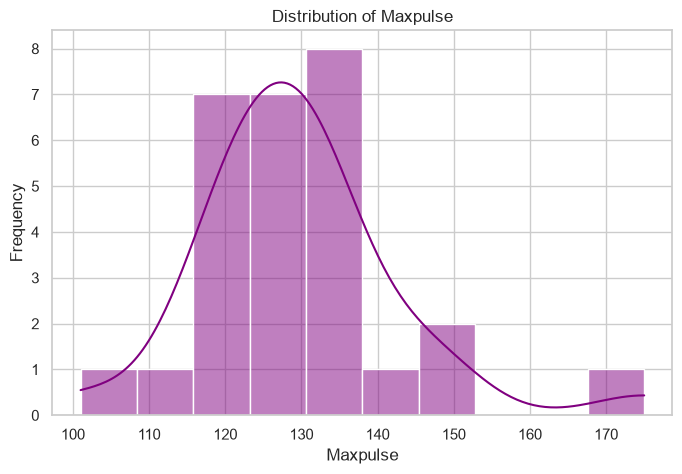

In [45]:
# frequency of any thing 
plt.figure(figsize=(8, 5))
sns.histplot(df['Maxpulse'], kde=True, color='purple', bins=10)
plt.title('Distribution of Maxpulse')
plt.xlabel('Maxpulse')
plt.ylabel('Frequency')
plt.show()

Findings & Interpretation: The histogram shows that **most maxpulse are between 120 and 138 maxpulse.**


####  4. BOX PLOT:

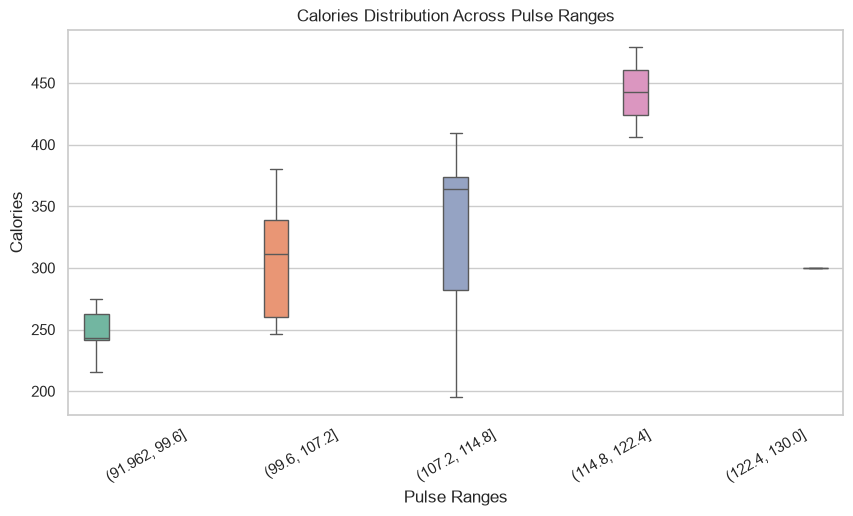

In [46]:
# 4. BOX PLOT (Seaborn): Pulse grouped or binned against Calories
# Since Pulse is continuous, we can bin it into categories to show distribution of Calories per Pulse range
df['Pulse_Group'] = pd.cut(df['Pulse'], bins=5)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='Pulse_Group',
    y='Calories',
    hue='Pulse_Group',
    palette='Set2',
    legend=False,
)
plt.title('Calories Distribution Across Pulse Ranges')
plt.xlabel('Pulse Ranges')
plt.ylabel('Calories')
plt.xticks(rotation=30)  # Rotate labels for clear readability
plt.show()

Findings & Interpretation: The visualization reveals a clear upward trend where **higher pulse ranges correspond to higher median calories** from around 250 calories in the lowest pulse bracket up to roughly 450 in the second-highest). However, the highest pulse bin displays a flat line due to a single data point sample size constraint, highlighting that higher-intensity pulse brackets require more observations for a complete spread distribution.

#### 5. Stripplot or Swarmplot

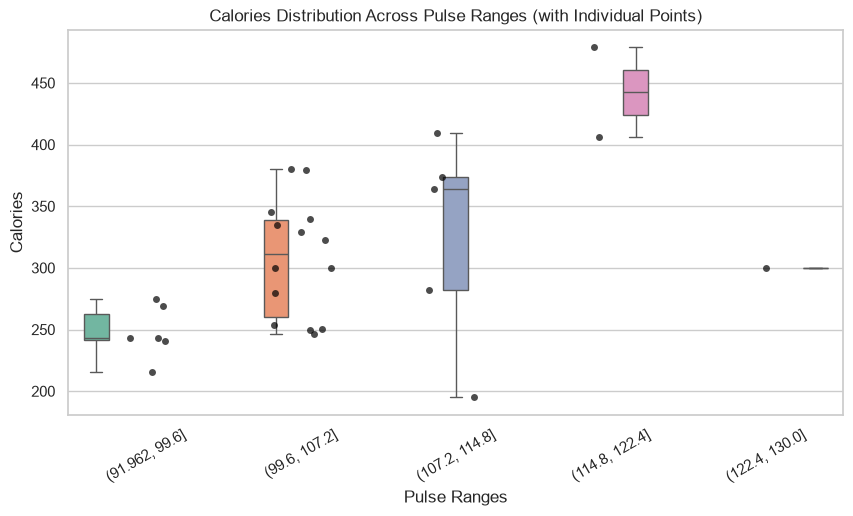

In [47]:
plt.figure(figsize=(10, 5))
# Use stripplot or swarmplot to see individual data points clearly
sns.boxplot(
    data=df,
    x='Pulse_Group',
    y='Calories',
    hue='Pulse_Group',
    palette='Set2',
    legend=False,
)
sns.stripplot(
    data=df,
    x='Pulse_Group',
    y='Calories',
    color='black',
    alpha=0.7,
    jitter=0.2,
)

plt.title('Calories Distribution Across Pulse Ranges (with Individual Points)')
plt.xlabel('Pulse Ranges')
plt.ylabel('Calories')
plt.xticks(rotation=30)
plt.show()

Findings & Interpretation: It clearly exposes that the **final sparse pulse bracket (122.4, 130.0]** contains precisely **one data point sitting at 300 calories**,
     while the **second bin (99.6, 107.2]** is **heavily populated** with 14 individuals.

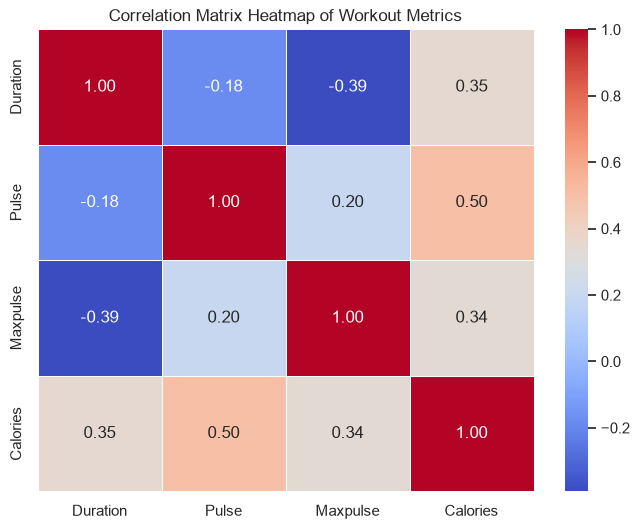

In [48]:
# Select only numerical columns and compute correlation
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Correlation Matrix Heatmap of Workout Metrics')
plt.show()

Findings & Interpretation: The **heatmap reveals that Pulse and Calories share the strongest positive linear correlation (r = 0.50).**
    
     Meanwhile, variables like Duration show a moderate positive link (r = 0.35), and Maxpulse exhibits a slight negative correlation with Duration (r = -0.39).

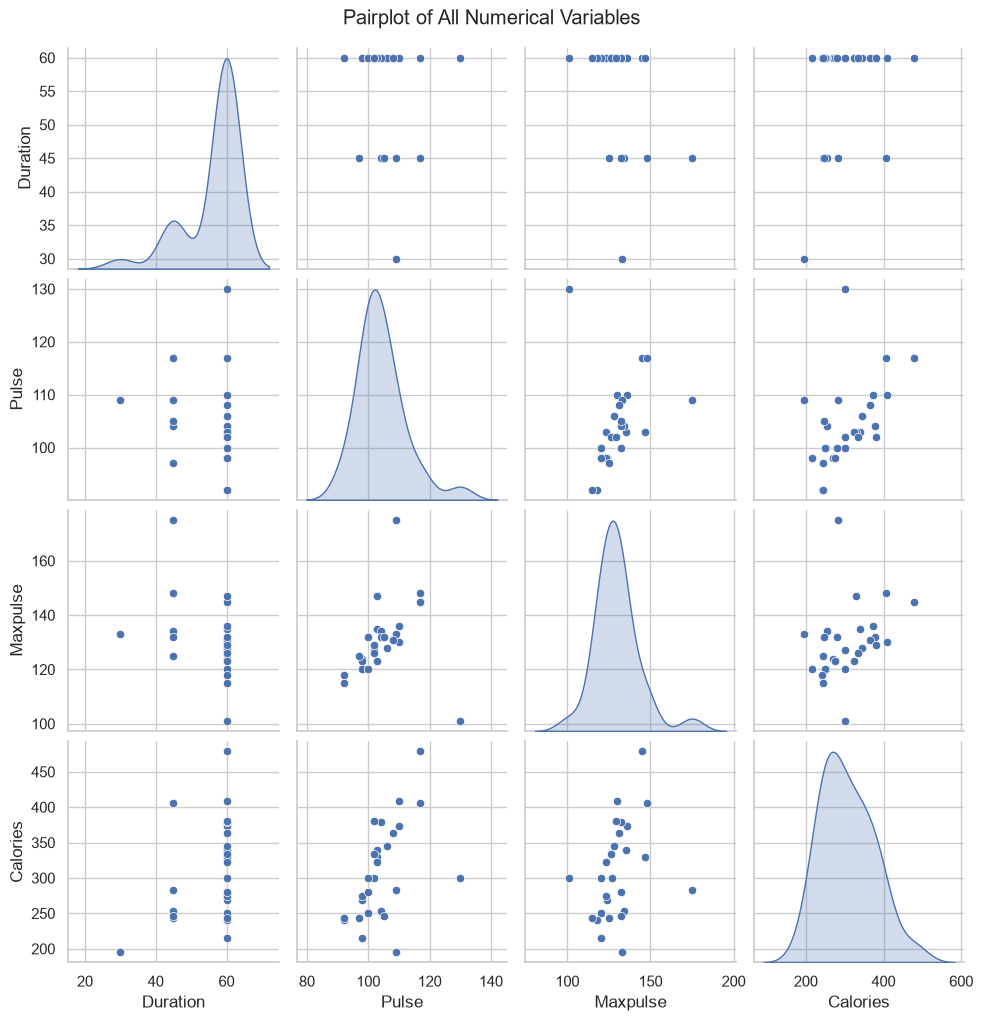

In [49]:
# Create a grid of scatter plots for all numerical columns
sns.pairplot(df.select_dtypes(include=['number']), diag_kind='kde')
plt.suptitle('Pairplot of All Numerical Variables', y=1.02)
plt.show()

Findings & Interpretation: 

**Clustering of Duration values (concentrated heavily at 60 minutes)**,

while **visually reinforcing how metrics like Pulse and Calories scale together.**

Maxpulse vs. Calories Relationship: The intersection grid between Maxpulse and Calories reveals a positive, upward-trending dispersion

with a correlation coefficient of r = 0.34. But weaker correlation coefficient compared to Pulse Vs Calories